| [![home](../media/navigation/home.png)](../index.html) | [![next](../media/navigation/next.png)](../lectures/chapter-01-02.html) |
| :---: |:-----------------------------------------------------------------------:|
| • |                      Chapter 1.2: Machine Learning                      |

# 2.4 Introduction to deep-learning

In the first part we will first introduce the basic concepts of Artificial Neural Networks (ANNs) loosely following some of the early landmark publications in the field. Before we introduce the important concepts of today's neural networks: optimizers, mini batches, activation functions and loss functions.

In the second part we will more specifically examine ANNs for image analysis and introduce convolutional neural networks, autoencoders and the UNet.

## 2.4.1 Introduction to Artificial Neural Networks

<div style="background-color: white">
<center>
<img width='85%' background="white" src="../media/chapter02_04/anns_timeline.png" alt="ANNs timeline" >
<br>
<small style="color: black">
Fig. 2.4.1 &ndash; A timeline of some of the landmark publications concerning ANNs.
</small>
</center>
</div>

In 1942 McCulloch and Pitts introduced a simplified mathematical model of neurons, which connected in a network can calculate all logical functions. Inspired by the McCulloch-Pitts Neuron, Rosenblatt published "The perceptron" in 1858. The perceptron resembles in many aspects the fully connected ANNs we use today. However, the learning took place by reinforcement learning, tweaking the parameters of the single inner layer to adjust the answers of the perceptron into the right direction. While multi-layer perceptrons were discussed, nobody knew how to train them. In 1969, Minsky and Papert demonstrated the severe restrictions of the single layer perceptron, starting the first AI winter. In 1970 Seppo Linnainmaa, published the back-propagation algorithm, in a context different from ANNs, in his master thesis. The back-propagation algorithm is what we use today to train deep learning networks. His publication remained unnoticed for a long time. In 1986 Rumelhart et al. applied the back-propagation to ANNs, which led to the end of the first AI-winter.

#### 2.4.1.1 The McCulloch-Pitts Neuron

<center>
<div style="width:60%; margin: auto;">
<div style="width:60%;  float:top; ">
<img src="../media/chapter02_04/natural_neuron.png"   alt="natural neuron">
<br>
<small>
Fig. 2.4.2 &ndash; Scheme of a natural neuron.
</small>
</div>
<div style="width:35%; float:top;  ">
<img src="../media/chapter02_04/mccp_neuron.png" alt="3d Gaussian" >
<br>
<small>
Fig. 2.4.3 &ndash; Scheme of a McCulloch-Pitts Neuron.
</small>
</div>
</div>
</center>

The McCulloch-Pitts Neuron has a number of incoming synapses and one output. The incoming synapsis can be inhibiting or exciting. When at least one inhibiting synapse is active the output is zero. If no inhibiting synapse is active, the output is one if more than a number g of exciting synapses are active and zero otherwise. [1]

It is easy to prove that a network of McCulloch-Pitts Neurons can calculate any logical function. We know that with combinations of NOT, AND and OR, we can calculate any logical function. If we can show that we can implement these three logical functions with the neurons, we have proven that we can calculate any logical function with them. You find the neurons for the AND, OR and NOT operations in the figures 2.4.4-2.4.6. [6]

<center>
<div style="width:75%; margin: auto;">
<div style="width:33%;  float:left; ">
<img src="../media/chapter02_04/not.png"   alt="not neuron">
<br>
<small>
Fig. 2.4.4 &ndash; The neuron for the NOT function only has one inhibiting synapse.
</small>
</div>
<div style="width:33%; float:left;  ">
<img src="../media/chapter02_04/and.png" alt="and neuron" >
<br>
<small>
Fig. 2.4.5 &ndash; The neuron for the AND operation is one, when the two exciting synapses are active.
</small>
</div>
<div style="width:33%; float:left;  ">
<img src="../media/chapter02_04/or.png" alt="or neuron" >
<br>
<small>
Fig. 2.4.6 &ndash; The neuron for the OR operation is one, when at least one of the two exciting synapses is active.
</small>
</div>
</div>
</center>

#### 2.4.1.2 The perceptron

The artificial neurons in an ANN are usually organized in layers. We call an ANN a Feed-Forward Neural Network (FNN), when the inputs for the neurons in each layer only come from neurons in the preceding layer. In a Recurrent Neural Networks (RNN), the input for neurons in a layer can come from the preceding layer and from any of the succeeding layers. The perceptron is a Feed-Forward Network.

<div>
<center>
<img width='45%' src="../media/chapter02_04/fnnrnn.png" alt="FNN/RNN" >
<br>
<small>
Fig. 2.4.7 &ndash; A FNN on the left side and a RNN on the right side.
</small>
</center>
</div>

The neurons used in the perceptron differ from the McCulloch-Pitts Neurons. There are no more inhibiting and exciting synapses. In the perceptron a weighted sum of the input values of a neuron is calculated and if it is above a threshold value the output of the neuron is one, otherwise it is minus one. The parameters of neuron are the weights of the incoming connections and the threshold value. The neurons were divided into sensory units, that receive the input values, association units that do the calculations and response units that indicate the results.

<center>
<div style="width:80%; margin: auto;">
<div style="width:45%;  float:left; ">
<img src="../media/chapter02_04/perceptron_neuron.png"   alt="perceptron neuron">
<br>
<small>
Fig. 2.4.8 &ndash; The neuron of a perceptron calculates a weighted sum of the input and uses a threshold function as activation.
</small>
</div>
<div style="width:25%; float:left;  ">
<img src="../media/chapter02_04/threshold_activation.png" alt="threshold activation" >
<br>
<small>
Fig. 2.4.9 &ndash; The activation function answers minus one for values below the threshold and one for values above the threshold.
</small>
</div>
</div>
</center>

Note that we could express the threshold by just using a step function that maps values below zero to minus one and values above zero to one. We could then add an input that is constantly 1 and its weight, which we would call the ``bias`` would move the step function to any value we want. The advantage of this scheme is that we do not need two different concepts, input weights and threshold value. We could treat the bias and the input weights in the same way.

<div style='background: white'>
<center>
<img width='45%' src="../media/chapter02_04/bias_step.png" alt="bias" >
<br>
<small style="color: black">
Fig. 2.4.10 &ndash; We can use a bias and a fixed step function instead of a threshold.
</small>
</center>
</div>

A single layer perceptron only has input neurons and output neurons. An output neuron has the value 1 if the weighted sum of its input is above a threshold and minus one otherwise.

<center>
<div style="width:80%; margin: auto;">
<div style="width:50%;  float:left; ">
<img width='45%' src="../media/chapter02_04/single.png" alt="single layer perceptron" >
<br>
<small>
Fig. 2.4.11 &ndash; A single layer perceptron has no hidden layers.
</small>
</div>
<div style="width:50%; float:left;  ">
<img width='55%' src="../media/chapter02_04/multi.png" alt="multi layer perceptron" >
<br>
<small>
Fig. 2.4.12 &ndash; A multi layer perceptron has at least one hidden layer.
</small>
</div>
</div>
</center>

In modern ANNs we call fully connected multi layer networks multi-layer perceptrons. The threshold is replaced by a bias and the step function is replaced by a continuous activation function, since the modern training method usually needs a continuous function. The layers between the input and output layers are called hidden layers. An ANN is called ``deep`` when it has at least two hidden layers and we talk about ``deep-learning`` in this case.

The training of the single layer perceptron repeats two steps a number of times N. We call N the number of ``epochs``. The first step is the forward pass. In the forward pass the output of the network is calculated. Then the loss is calculated as the difference between the output and the ground truth for each output neuron. In the second step the weights are adjusted. To each weight of a connection between an input and an output neuron, the product of the loss, the input and the learning rate is added.

#### 2.4.1.3 Restrictions of the single layer perceptron

A single layer perceptron can only create linear decision boundaries, since it applies a step function to a linear combination of the inputs. It can not calculate the simple xor function. The xor function takes two boolean values as input and answers true if and only if exactly one of the arguments is true. Drawing the combination of input values as coordinates in a plane, you can see that no linear decision boundary can separate the input values that have to yield false from those that have to yield true.

<div style="background-color: white">
<center>
<img width='45%' background="white" src="../media/chapter02_04/xor.png" alt="xor" >
<br>
<small style="color: black">
Fig. 2.4.13 &ndash; A linear decision boundary can calculate the or function, but not the xor function.
</small>
</center>
</div>

#### 2.4.1.4 The back-propagation algorithm

The severe restrictions of the single layer perceptron can be overcome by a multi-layer perceptron. But how can a multi-layer perceptron be trained? The output of a response neuron depends, on all the inner neurons in the previous layer, and their output depends on the neurons in the layer before, and so on. We can calculate the forward step for a given input and the loss function by comparing the output to the ground-truth. We know that we can apply gradient descent to solve an optimization problem. But to do that, we need to know the gradients for all the parameters (weights and biases). And that is what the back-propagation algorithm calculates for a given loss.

The basis for the back-propagation algorithm is the chain rule. The chain rule tells us that the derivative of a composite function is the derivative of the outer function multiplied by the derivative of the inner function.

$$
  h(x) = f\left(g\left(x\right)\right)  ~~~~~~~~~~~~ (1)
$$

$$
  h'(x) = f'(g(x)) \times g'(x) ~~~~~~~~~~~~ (2)
$$

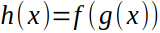

In the case, that $g$ is itself a composite function, we just can just apply the chain rule to this inner function again.

It works similar when we have more than one argument.

$$
    F(s,t) = f\left(x\left(s, t\right), y\left(s,t\right)\right)  ~~~~~~~~~~~~ (3)
$$

$$
    \frac{\partial F}{\partial s} = \frac{\partial f}{\partial x} \frac{\partial x}{\partial s} + \frac{\partial f}{\partial y} \frac{\partial y}{\partial s}  ~~~~~~~~~~~~ (4)
$$

$$
    \frac{\partial F}{\partial t} = \frac{\partial f}{\partial x} \frac{\partial x}{\partial t} + \frac{\partial f}{\partial y} \frac{\partial y}{\partial t}  ~~~~~~~~~~~~ (5)
$$

# Literature

1. <a href="lit-ref-01"></a>McCulloch, W.S., and Pitts, W. (1943). [A logical calculus of the ideas immanent in nervous activity](https://doi.org/10.1007/BF02478259). The bulletin of mathematical biophysics 5, 115–133.
2. <a href="lit-ref-02"></a>Rosenblatt, F. (1958). [The perceptron: A probabilistic model for information storage and organization in the brain](https://doi.org/10.1037/h0042519). Psychological Review 65, 386–408.
3. <a href="lit-ref-03"></a>Minsky, M., and Papert, S.A. (2017). [Perceptrons: An Introduction to Computational Geometry](https://doi.org/10.7551/mitpress/11301.001.0001) (The MIT Press).
4. <a href="lit-ref-04"></a>Linnainmaa, Seppo (1970). Algoritmin kumulatiivinen pyöristysvirhe yksittäisten pyöristysvirheiden Taylor-kehitelmänä [The representation of the cumulative rounding error of an algorithm as a Taylor expansion of the local rounding errors] (Thesis) (in Finnish).
5. <a href="lit-ref-05"></a>Rumelhart, D.E., Hinton, G.E., and Williams, R.J. (1986). [Learning representations by back-propagating errors](https://doi.org/10.1038/323533a0). Nature 323, 533–536.
6. <a href="lit-ref-06"></a>McCulloch-Pitts Neuron — Mankind’s First Mathematical Model Of A Biological Neuron, Akshay L Chandra, 2018, Towards Data Science